In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

df = pd.read_csv('jeeves_tennis.csv')

print("Dataset Loaded:")
print(df.head())

Dataset Loaded:
   Day_ID   Outlook  Temperature Humidity    Wind PlayTennis
0       1      Rain         19.2     High  Strong         No
1       2      Rain         17.4      Low    Weak        Yes
2       3     Sunny         29.9   Normal  Strong        Yes
3       4  Overcast         23.2   Normal    Weak        Yes
4       5     Sunny         29.3     High    Weak         No


In [16]:
def calculate_entropy(y):
    class_counts = y.value_counts()
    probabilities = class_counts / len(y)
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy


def calculate_info_gain_discrete(df, feature, target):
    total_entropy = calculate_entropy(df[target])
    values = df[feature].unique()
    weighted_entropy = 0
    for value in values:
        subset = df[df[feature] == value]
        prob = len(subset) / len(df)
        weighted_entropy += prob * calculate_entropy(subset[target])

    return total_entropy - weighted_entropy


gain_day_id = calculate_info_gain_discrete(df, 'Day_ID', 'PlayTennis')
print(f"Information Gain for Day_ID: {gain_day_id:.4f}")

df_clean = df.drop('Day_ID', axis=1)

Information Gain for Day_ID: 0.9815


In [17]:
features = ['Outlook', 'Humidity', 'Wind']
target = 'PlayTennis'

print("\n--- Root Node Selection (Discrete Features) ---")
best_gain = -1
best_feature = None

for feat in features:
    gain = calculate_info_gain_discrete(df_clean, feat, target)
    print(f"Feature: {feat:<10} | Gain: {gain:.4f}")
    if gain > best_gain:
        best_gain = gain
        best_feature = feat


--- Root Node Selection (Discrete Features) ---
Feature: Outlook    | Gain: 0.3431
Feature: Humidity   | Gain: 0.0539
Feature: Wind       | Gain: 0.0382


In [18]:
def find_best_split(data, attribute, target):
    sorted_data = data.sort_values(by=attribute)

    unique_values = sorted_data[attribute].unique()
    split_points = []

    for i in range(len(unique_values) - 1):
        midpoint = (unique_values[i] + unique_values[i+1]) / 2
        split_points.append(midpoint)

    best_gain = -1
    best_threshold = None
    parent_entropy = calculate_entropy(data[target])

    for threshold in split_points:
        left_subset = data[data[attribute] <= threshold]
        right_subset = data[data[attribute] > threshold]

        n = len(data)
        p_left = len(left_subset) / n
        p_right = len(right_subset) / n

        weighted_entropy = (p_left * calculate_entropy(left_subset[target])) + \
                           (p_right * calculate_entropy(right_subset[target]))

        gain = parent_entropy - weighted_entropy

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold, best_gain


best_t, best_g = find_best_split(df_clean, 'Temperature', 'PlayTennis')
print(f"Optimal Split for Temperature: <= {best_t:.2f}")
print(f"Gain for Temperature: {best_g:.4f}")

Optimal Split for Temperature: <= 30.05
Gain for Temperature: 0.0239


In [19]:
class Node:
    def __init__(self, feature=None, threshold=None, value=None, left=None, right=None, children=None):
        self.feature = feature
        self.threshold = threshold
        self.value = value
        self.children = children
        self.left = left
        self.right = right


class DecisionTreeID3:
    def __init__(self, min_samples_split=2, max_depth=100):
        self.root = None
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth

    def fit(self, X, y):
        data = X.copy()
        data['target'] = y
        self.root = self._build_tree(data, depth=0)

    def _build_tree(self, data, depth):
        X, y = data.drop('target', axis=1), data['target']
        n_samples, n_features = X.shape
        n_labels = len(y.unique())

        if (n_samples < self.min_samples_split or
            n_labels == 1 or
                depth >= self.max_depth):
            leaf_value = y.mode()[0]
            return Node(value=leaf_value)

        best_feat, best_gain, best_thresh = self._get_best_split(
            data, X.columns)

        if best_gain == 0:
            return Node(value=y.mode()[0])

        if best_thresh is None:
            node = Node(feature=best_feat, children={})
            for val in data[best_feat].unique():
                subset = data[data[best_feat] == val]
                if len(subset) == 0:
                    node.children[val] = Node(value=y.mode()[0])
                else:
                    node.children[val] = self._build_tree(subset, depth + 1)
            return node
        else:
            node = Node(feature=best_feat, threshold=best_thresh)
            left_data = data[data[best_feat] <= best_thresh]
            right_data = data[data[best_feat] > best_thresh]
            node.left = self._build_tree(left_data, depth + 1)
            node.right = self._build_tree(right_data, depth + 1)
            return node

    def _get_best_split(self, data, features):
        best_gain = -1
        best_feat = None
        best_thresh = None

        for feat in features:
            if np.issubdtype(data[feat].dtype, np.number):
                thresh, gain = find_best_split(data, feat, 'target')
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thresh = thresh
            else:
                gain = calculate_info_gain_discrete(data, feat, 'target')
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thresh = None

        return best_feat, best_gain, best_thresh

    def predict(self, X):
        return [self._predict_one(sample, self.root) for _, sample in X.iterrows()]

    def _predict_one(self, sample, node):
        if node.value is not None:
            return node.value

        val = sample[node.feature]

        if node.threshold is None:
            if val in node.children:
                return self._predict_one(sample, node.children[val])
            else:
                return "No"
        else:
            if val <= node.threshold:
                return self._predict_one(sample, node.left)
            else:
                return self._predict_one(sample, node.right)

In [20]:
X = df_clean.drop('PlayTennis', axis=1)
y = df_clean['PlayTennis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

tree = DecisionTreeID3(max_depth=5)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(
    y_test, y_pred, pos_label='Yes', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, pos_label='Yes', zero_division=0))

Accuracy: 0.94
Precision: 0.9491525423728814
Recall: 0.9491525423728814


Clean Tree - Depth: 12, Leaves: 44
Noisy Tree - Depth: 16, Leaves: 137
Effect of Noise: Tree grew by 93 leaves.


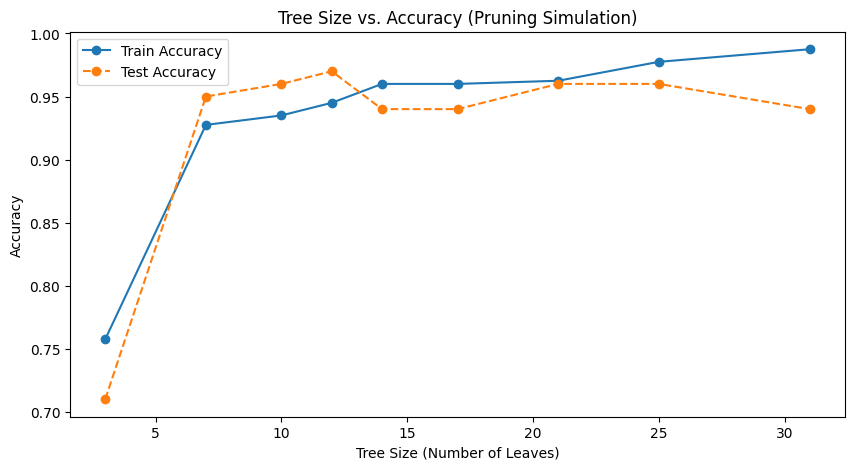

In [21]:
def get_tree_size(node):
    if node.value is not None:
        return 1, 1

    depths = []
    leaves = 0
    if node.threshold is None:
        for child in node.children.values():
            d, l = get_tree_size(child)
            depths.append(d)
            leaves += l
    else:
        dl, ll = get_tree_size(node.left)
        dr, lr = get_tree_size(node.right)
        depths.extend([dl, dr])
        leaves += ll + lr

    return 1 + max(depths), leaves


full_tree = DecisionTreeID3(max_depth=100)
full_tree.fit(X, y)
depth, leaves = get_tree_size(full_tree.root)
print(f"Clean Tree - Depth: {depth}, Leaves: {leaves}")

y_noisy = y.copy()
n_noise = int(0.1 * len(y))
noise_indices = np.random.choice(len(y), n_noise, replace=False)
for idx in noise_indices:
    y_noisy.iloc[idx] = 'No' if y_noisy.iloc[idx] == 'Yes' else 'Yes'

noisy_tree = DecisionTreeID3(max_depth=100)
noisy_tree.fit(X, y_noisy)
d_noise, l_noise = get_tree_size(noisy_tree.root)
print(f"Noisy Tree - Depth: {d_noise}, Leaves: {l_noise}")
print(f"Effect of Noise: Tree grew by {l_noise - leaves} leaves.")

depths = range(1, 10)
train_accs = []
test_accs = []
sizes = []

for d in depths:
    t = DecisionTreeID3(max_depth=d)
    t.fit(X_train, y_train)

    train_accs.append(accuracy_score(y_train, t.predict(X_train)))
    test_accs.append(accuracy_score(y_test, t.predict(X_test)))
    _, l = get_tree_size(t.root)
    sizes.append(l)

plt.figure(figsize=(10, 5))
plt.plot(sizes, train_accs, marker='o', label='Train Accuracy')
plt.plot(sizes, test_accs, marker='o', label='Test Accuracy', linestyle='--')
plt.xlabel('Tree Size (Number of Leaves)')
plt.ylabel('Accuracy')
plt.title('Tree Size vs. Accuracy (Pruning Simulation)')
plt.legend()
plt.show()